# Notebook 04 — Optimización Tiempo-Óptima de Trayectoria

## Objetivo
Encontrar la trayectoria que minimiza el **tiempo de vuelta real**:

$$T = \sum_i \frac{\Delta s_i}{v_i}$$

El optimizador equilibra automáticamente el trade-off fundamental:
- Mayor radio de curva → mayor velocidad, pero más distancia
- Línea más corta → menos distancia, pero más curvatura y menor velocidad

## Implementación (2 fases)
- **DE (exploración global):** búsqueda estocástica global con física completa
- **L-BFGS-B (refinamiento):** convergencia local de precisión

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, minimize
from scipy.signal import savgol_filter
import time
import warnings
warnings.filterwarnings('ignore')

# Circuito de referencia (centro geométrico de las 5 mejores vueltas)
circuito  = pd.read_csv('../data/circuito_barcelona_2024.csv')
x_ref     = circuito['x'].values
y_ref     = circuito['y'].values
kappa_ref = circuito['kappa'].values
dist_ref  = circuito['dist'].values
N         = len(x_ref)

print(f'Circuito referencia: {N} puntos, {dist_ref[-1]:.1f} m')

Circuito referencia: 2000 puntos, 4610.9 m


In [2]:
# ── Parámetros físicos ────────────────────────────────────────────────────────
G            = 9.81
MU           = 2.5
k_drag       = 0.0012
k_downforce  = 0.0010
A_LON        = MU * G * 0.90
A_FREN       = MU * G * 1.30
# V_MAX y V_MAX_DRS se extraen de telemetría en f497a017:
#   V_MAX     = tope sin DRS (limitado por motor en zonas sin recta larga)
#   V_MAX_DRS = tope con DRS abierto (recta principal, ~340 km/h)
V_MAX        = 88.9    # placeholder (~320 km/h), se sobreescribe en f497a017
V_MAX_DRS    = 94.4    # placeholder (~340 km/h), se sobreescribe en f497a017
V_MIN        = 8.0
POLE_TIME    = 71.383

# ── Geometría de pista ────────────────────────────────────────────────────────
ANCHO_PISTA  = 12.0
MARGEN       = 0.5
d_max        = ANCHO_PISTA / 2.0 - MARGEN

# ── Límite de curvatura físico ────────────────────────────────────────────────
# R_min ~30 m: curva más cerrada del trazado 2024 (Turn 9).
# El circuito 2024 no incluye la chicane del sector 3 (eliminada ese año).
# Valores κ > 1/30 son artefactos de np.gradient, no geometría real.
KAPPA_MAX    = 1.0 / 30.0

# ── Espacio de optimización ───────────────────────────────────────────────────
N_CTRL       = 80
POP_SIZE     = 8
N_INDIVIDUOS = POP_SIZE * N_CTRL
idx_ctrl     = np.linspace(0, N - 1, N_CTRL, dtype=int)
t_ctrl       = idx_ctrl / (N - 1)
t_all        = np.arange(N) / (N - 1)
bounds       = [(-d_max, d_max)] * N_CTRL

def expandir(n_ctrl):
    return np.interp(t_all, t_ctrl, n_ctrl)

# ── DRS ───────────────────────────────────────────────────────────────────────
drs_mask   = np.zeros(N, dtype=np.bool_)
DRS_FACTOR = 0.85   # reducción de drag con DRS abierto (~15%)

print('Parámetros físicos cargados (V_MAX/V_MAX_DRS se actualizan desde telemetría).')
print(f'  A_LON : {A_LON:.2f} m/s²  |  A_FREN : {A_FREN:.2f} m/s²')
print(f'  Límite pista: ±{d_max} m  |  N_CTRL: {N_CTRL}  |  N_INDIVIDUOS: {N_INDIVIDUOS}')
print(f'  KAPPA_MAX: {KAPPA_MAX:.5f} 1/m  (R_min = {1/KAPPA_MAX:.0f} m)')

Parámetros físicos cargados (V_MAX/V_MAX_DRS se actualizan desde telemetría).
  A_LON : 22.07 m/s²  |  A_FREN : 31.88 m/s²
  Límite pista: ±5.5 m  |  N_CTRL: 80  |  N_INDIVIDUOS: 640
  KAPPA_MAX: 0.03333 1/m  (R_min = 30 m)


In [3]:
# ── Funciones geométricas ──────────────────────────────────────────────────────
def calcular_normales(x, y):
    dx = np.gradient(x)
    dy = np.gradient(y)
    L  = np.sqrt(dx**2 + dy**2)
    L  = np.where(L < 1e-9, 1e-9, L)
    return -dy / L, dx / L

def calcular_curvatura(x, y):
    dx  = np.gradient(x);  dy  = np.gradient(y)
    ddx = np.gradient(dx); ddy = np.gradient(dy)
    den = (dx**2 + dy**2)**1.5
    den = np.where(den < 1e-9, 1e-9, den)
    return (dx * ddy - dy * ddx) / den

nx, ny = calcular_normales(x_ref, y_ref)

def v_lateral_vec(kappa_abs):
    """Velocidad límite lateral: v²/R = a_lim = μg + k_df·v² (punto fijo).
    Consistente con el modelo de grip del integrador forward-backward."""
    kappa_safe = np.where(kappa_abs < 1e-6, 1e-6, kappa_abs)
    R          = 1.0 / kappa_safe
    vmax_local = np.where(drs_mask, V_MAX_DRS, V_MAX)
    v = np.full_like(R, 50.0)
    for _ in range(10):
        a_lim = MU * G + k_downforce * v**2
        v_new = np.sqrt(a_lim * R)
        v_new = np.clip(v_new, V_MIN, vmax_local)
        if np.max(np.abs(v_new - v)) < 0.01:
            break
        v = v_new
    return v_new

print('Funciones geométricas y v_lateral_vec definidas.')

Funciones geométricas y v_lateral_vec definidas.


In [4]:
# ── Integración forward-backward con círculo de fricción y DRS ─────────────────
#
#   a_lim(v)    = μg + k_df·v²
#   a_lat       = v²·κ
#   a_lon_avail = sqrt(a_lim² - a_lat²)
#   En zona DRS: k_drag *= DRS_FACTOR  y  tope de velocidad = V_MAX_DRS
#
try:
    from numba import njit

    @njit(cache=True)
    def _fb_numba(v_cap, ds, kappa, a_lon_max, a_fren_max, k_d, k_df, mu_g,
                  vmax, vmin, drs_active, k_d_drs, vmax_drs):
        N = len(v_cap)
        v = v_cap.copy()
        for i in range(1, N):
            vp    = v[i-1]
            kd_i  = k_d_drs if drs_active[i-1] else k_d
            vm_i  = vmax_drs if drs_active[i-1] else vmax
            a_lim = mu_g + k_df * vp * vp
            a_lat = vp * vp * kappa[i-1]
            if a_lat > a_lim: a_lat = a_lim
            a_lon_avail = (max(0.0, a_lim*a_lim - a_lat*a_lat))**0.5
            ae = min(a_lon_max, a_lon_avail) - kd_i * vp * vp
            if ae < 0.0: ae = 0.0
            vn = (vp*vp + 2.0*ae*ds[i-1])**0.5
            if vn > vm_i:     vn = vm_i
            if vn > v_cap[i]: vn = v_cap[i]
            v[i] = vn
        vb = v.copy()
        for i in range(N-2, -1, -1):
            vn    = vb[i+1]
            kd_i  = k_d_drs if drs_active[i+1] else k_d
            a_lim = mu_g + k_df * vn * vn
            a_lat = vn * vn * kappa[i+1]
            if a_lat > a_lim: a_lat = a_lim
            a_fren_avail = (max(0.0, a_lim*a_lim - a_lat*a_lat))**0.5
            ae = min(a_fren_max, a_fren_avail) + kd_i * vn * vn
            vp = (vn*vn + 2.0*ae*ds[i])**0.5
            if vp > v[i]: vp = v[i]
            vb[i] = vp
        return vb

    _d   = np.ones(10, dtype=np.float64)
    _ds  = np.full(9, 2.0, dtype=np.float64)
    _k   = np.full(10, 0.01, dtype=np.float64)
    _drs = np.zeros(10, dtype=np.bool_)
    _fb_numba(_d, _ds, _k, A_LON, A_FREN, k_drag, k_downforce, MU*G,
              V_MAX, V_MIN, _drs, k_drag * DRS_FACTOR, V_MAX_DRS)

    def forward_backward(v_cap, ds, kappa):
        return _fb_numba(
            v_cap.astype(np.float64), ds.astype(np.float64), kappa.astype(np.float64),
            A_LON, A_FREN, k_drag, k_downforce, MU*G, V_MAX, V_MIN,
            drs_mask, k_drag * DRS_FACTOR, V_MAX_DRS,
        )

    print('✅ Numba — forward-backward con círculo de fricción + DRS')

except ImportError:
    def forward_backward(v_cap, ds, kappa):
        N  = len(v_cap)
        v  = v_cap.copy()
        for i in range(1, N):
            vp    = v[i-1]
            kd_i  = k_drag * DRS_FACTOR if drs_mask[i-1] else k_drag
            vm_i  = V_MAX_DRS if drs_mask[i-1] else V_MAX
            a_lim = MU*G + k_downforce * vp**2
            a_lat = min(vp**2 * kappa[i-1], a_lim)
            a_lon_avail = max(0.0, a_lim**2 - a_lat**2)**0.5
            ae = max(min(A_LON, a_lon_avail) - kd_i * vp**2, 0.0)
            v[i] = min((vp**2 + 2*ae*ds[i-1])**0.5, vm_i, v_cap[i])
        vb = v.copy()
        for i in range(N-2, -1, -1):
            vn    = vb[i+1]
            kd_i  = k_drag * DRS_FACTOR if drs_mask[i+1] else k_drag
            a_lim = MU*G + k_downforce * vn**2
            a_lat = min(vn**2 * kappa[i+1], a_lim)
            a_fren_avail = max(0.0, a_lim**2 - a_lat**2)**0.5
            ae = min(A_FREN, a_fren_avail) + kd_i * vn**2
            vb[i] = min((vn**2 + 2*ae*ds[i])**0.5, v[i])
        return vb

    print('⚠️  Numba no disponible')

✅ Numba — forward-backward con círculo de fricción + DRS


In [5]:
# ── Función objetivo: tiempo de vuelta real ∑(Δs/v) ──────────────────────────
_PAD = 25  # padding periódico para evitar artefacto de curvatura en la unión inicio/fin

def _prep(n_ctrl):
    n_full = expandir(n_ctrl)
    x_new  = x_ref + nx * n_full
    y_new  = y_ref + ny * n_full
    ds     = np.maximum(np.sqrt(np.diff(x_new)**2 + np.diff(y_new)**2), 1e-6)
    # Padding periódico antes de calcular curvatura y aplicar Savgol
    x_per  = np.concatenate([x_new[-_PAD:], x_new, x_new[:_PAD]])
    y_per  = np.concatenate([y_new[-_PAD:], y_new, y_new[:_PAD]])
    kappa  = savgol_filter(np.abs(calcular_curvatura(x_per, y_per)), 21, 3)
    kappa  = np.clip(kappa[_PAD:-_PAD], 0.0, KAPPA_MAX)
    return ds, kappa

def objetivo(n_ctrl):
    ds, kappa = _prep(n_ctrl)
    v_lat = v_lateral_vec(kappa)
    v     = forward_backward(v_lat, ds, kappa)
    v_seg = np.maximum((v[:-1] + v[1:]) / 2.0, V_MIN)
    return float(np.sum(ds / v_seg))

# Benchmark
n_test = np.zeros(N_CTRL)
_ = objetivo(n_test)  # warm-up
t0 = time.perf_counter()
for _ in range(200): objetivo(n_test)
ms = (time.perf_counter() - t0) / 200 * 1000

evals_de   = N_CTRL * POP_SIZE * 400
evals_bfgs = 50000
print(f'Coste por evaluación: {ms:.2f} ms')
print(f'DE estimado:     {evals_de} evals → ~{evals_de*ms/1000:.0f}s')
print(f'L-BFGS-B máximo: {evals_bfgs} evals → ~{evals_bfgs*ms/1000:.0f}s')

Coste por evaluación: 1.23 ms
DE estimado:     256000 evals → ~315s
L-BFGS-B máximo: 50000 evals → ~61s


In [6]:
# ── Parámetros físicos para clasificación ideal + máscara DRS ─────────────────
#
# MU=2.5, k_downforce=0.0028: físicamente motivados para F1 2024 Barcelona.
# k_drag: calibrado desde zonas de frenada (DRS siempre cerrado → drag base).
# drs_mask: interpolado desde el canal DRS de la telemetría de Norris.
#
# V_MAX_DRS: speed trap oficial FIA, Barcelona 2024 Q — Norris: 340 km/h.
#            La telemetría FastF1 (548 pts) no captura el pico real por muestreo
#            a ~8.5 m/punto; el speed trap es una medición puntual precisa.
# V_MAX:     no observable en esta vuelta (DRS abierto en todas las rectas largas).
#            Se deriva del equilibrio thrust=drag:
#              Thrust = k_drag · DRS_FACTOR · V_MAX_DRS²  (con DRS)
#              Thrust = k_drag · V_MAX²                   (sin DRS)
#            → V_MAX = V_MAX_DRS · √(DRS_FACTOR)
#
import fastf1
from scipy.interpolate import interp1d as sp_interp1d
fastf1.Cache.enable_cache('../cache')

session = fastf1.get_session(2024, 'Barcelona', 'Q')
session.load(telemetry=True, laps=True, weather=False, messages=False)
tel      = session.laps.pick_fastest().get_telemetry()
v_tel    = tel['Speed'].values / 3.6
dist_tel = tel['Distance'].values
thr_tel  = tel['Throttle'].values
brk_tel  = tel['Brake'].values.astype(float)
drs_tel  = tel['DRS'].values.astype(float)
ds_tel   = np.maximum(np.diff(dist_tel), 0.1)
print(f'Telemetría Norris: {len(v_tel)} puntos, {dist_tel[-1]:.0f}m')

# k_drag desde frenadas fuertes (DRS siempre cerrado al frenar → drag base)
frenada = (thr_tel[:-1] < 5) & (brk_tel[:-1] > 0.8) & (v_tel[:-1] > 50)
if frenada.sum() > 5:
    a_obs    = np.diff(v_tel**2) / (2 * ds_tel)
    v_mid    = (v_tel[:-1] + v_tel[1:]) / 2
    muestras = -(a_obs[frenada] + A_FREN) / (v_mid[frenada]**2)
    muestras = muestras[muestras > 0]
    k_drag_cal = float(np.median(muestras)) if len(muestras) > 3 else k_drag
    print(f'[k_drag]  {len(muestras)} muestras → {k_drag_cal:.6f}')
else:
    k_drag_cal = k_drag
    print(f'[k_drag]  sin muestras → {k_drag:.6f}')

# V_MAX_DRS: speed trap oficial FIA (medición puntual precisa)
V_MAX_DRS = 340.0 / 3.6

# V_MAX sin DRS: derivado del equilibrio thrust=drag
V_MAX = V_MAX_DRS * float(np.sqrt(DRS_FACTOR))

# Máscara DRS interpolada al grid del circuito
dist_clip  = np.clip(dist_ref, dist_tel[0], dist_tel[-1])
drs_interp = sp_interp1d(dist_tel, drs_tel, kind='nearest',
                          bounds_error=False, fill_value=0.0)(dist_clip)
drs_mask[:] = drs_interp >= 10

n_drs = drs_mask.sum()
changes = np.diff(drs_mask.astype(int))
starts  = list(np.where(changes == 1)[0] + 1)
ends    = list(np.where(changes == -1)[0] + 1)
if drs_mask[0]:  starts = [0] + starts
if drs_mask[-1]: ends   = ends + [N]
print(f'[DRS]  {n_drs} puntos activos ({n_drs/N*100:.1f}%)  |  {len(starts)} zona(s)')
for i, (s, e) in enumerate(zip(starts, ends)):
    print(f'       Zona {i+1}: dist {dist_ref[s]:.0f}–{dist_ref[min(e, N-1)]:.0f} m')
print(f'[V_MAX]  con DRS: {V_MAX_DRS*3.6:.1f} km/h (speed trap FIA)  |  sin DRS: {V_MAX*3.6:.1f} km/h (= 340·√{DRS_FACTOR})')

MU_cal          = 2.5
k_downforce_cal = 0.0028

print(f'\n=== PARÁMETROS CLASIFICACIÓN IDEAL ===')
print(f'  MU={MU_cal}  k_drag={k_drag_cal:.6f}  k_downforce={k_downforce_cal}  DRS_FACTOR={DRS_FACTOR}')
print(f'  Grip 150 km/h: {MU_cal*9.81 + k_downforce_cal*(150/3.6)**2:.1f} m/s²'
      f'  | 250 km/h: {MU_cal*9.81 + k_downforce_cal*(250/3.6)**2:.1f} m/s²'
      f'  | 300 km/h: {MU_cal*9.81 + k_downforce_cal*(300/3.6)**2:.1f} m/s²')

core           INFO 	Loading data for Spanish Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '44', '63', '16', '55', '10', '11', '31', '81', '14', '77', '27', '18', '24', '20', '22', '3', '23', '2']


Telemetría Norris: 548 puntos, 4638m
[k_drag]  13 muestras → 0.001217
[DRS]  513 puntos activos (25.7%)  |  3 zona(s)
       Zona 1: dist 0–739 m
       Zona 2: dist 2988–3385 m
       Zona 3: dist 4567–4611 m
[V_MAX]  con DRS: 340.0 km/h (speed trap FIA)  |  sin DRS: 313.5 km/h (= 340·√0.85)

=== PARÁMETROS CLASIFICACIÓN IDEAL ===
  MU=2.5  k_drag=0.001217  k_downforce=0.0028  DRS_FACTOR=0.85
  Grip 150 km/h: 29.4 m/s²  | 250 km/h: 38.0 m/s²  | 300 km/h: 44.0 m/s²


In [7]:
# ── Aplicar parámetros y optimizar ────────────────────────────────────────────
MU          = MU_cal
k_drag      = k_drag_cal
k_downforce = k_downforce_cal
A_LON       = MU * G * 0.90
A_FREN      = MU * G * 1.30

print(f'A_LON={A_LON:.2f} m/s²  A_FREN={A_FREN:.2f} m/s²')

t_centro_cal = objetivo(np.zeros(N_CTRL))
print(f'Tiempo referencia: {t_centro_cal:.3f}s  ({t_centro_cal - POLE_TIME:+.3f}s vs pole)')

rng      = np.random.default_rng(42)
init_pop = rng.uniform(-d_max, d_max, (N_INDIVIDUOS, N_CTRL))
init_pop[0] = np.zeros(N_CTRL)

print('\n[Fase 1] Evolución Diferencial...')
t0 = time.time()
res_global = differential_evolution(
    objetivo, bounds=bounds, maxiter=400, popsize=POP_SIZE, tol=1e-7,
    seed=42, init=init_pop, disp=False, workers=1,
    mutation=(0.5, 1.2), recombination=0.8,
)
t_de = time.time() - t0
print(f'  {t_de:.1f}s  |  Convergió: {res_global.success}  |  {res_global.fun:.3f}s  ({res_global.fun-POLE_TIME:+.3f}s)')

print('[Fase 2] L-BFGS-B...')
t1 = time.time()
res_local = minimize(
    objetivo, res_global.x, method='L-BFGS-B', bounds=bounds,
    options={'maxfun': 50000, 'ftol': 1e-14, 'gtol': 1e-9},
)
t_bfgs = time.time() - t1
print(f'  {t_bfgs:.1f}s  |  {"Convergió" if res_local.success else res_local.message}  |  {res_local.fun:.3f}s  ({res_local.fun-POLE_TIME:+.3f}s)')

n_opt = res_local.x
print(f'\nTotal: {t_de+t_bfgs:.1f}s  |  Mejora vs referencia: {t_centro_cal - res_local.fun:+.3f}s')

A_LON=22.07 m/s²  A_FREN=31.88 m/s²
Tiempo referencia: 71.657s  (+0.274s vs pole)

[Fase 1] Evolución Diferencial...
  348.9s  |  Convergió: False  |  70.492s  (-0.891s)
[Fase 2] L-BFGS-B...
  71.2s  |  STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT  |  70.474s  (-0.909s)

Total: 420.1s  |  Mejora vs referencia: +1.183s


In [8]:
# ── Post-procesado: trayectoria y perfil de velocidad final ───────────────────
from scipy.interpolate import splprep, splev

n_opt_full   = expandir(n_opt)
n_opt_smooth = savgol_filter(n_opt_full, window_length=51, polyorder=3)
n_opt_smooth = np.clip(n_opt_smooth, -d_max, d_max)

x_to = x_ref + nx * n_opt_smooth
y_to = y_ref + ny * n_opt_smooth

# Re-splinear la trayectoria óptima para curvatura analítica (sin artefactos de np.gradient)
_coords = np.column_stack([x_to, y_to])
_mask   = np.append(np.any(np.diff(_coords, axis=0) != 0, axis=1), True)
_xc, _yc = x_to[_mask], y_to[_mask]
if not (np.isclose(_xc[0], _xc[-1]) and np.isclose(_yc[0], _yc[-1])):
    _xc = np.append(_xc, _xc[0])
    _yc = np.append(_yc, _yc[0])
# s=0.01: casi interpolante, solo elimina ruido residual sin distorsionar la geometría
tck_to, _ = splprep([_xc, _yc], s=len(_xc) * 0.01, per=True, k=3)

u_to = np.linspace(0, 1, N, endpoint=False)
x_to, y_to = splev(u_to, tck_to)

# Curvatura analítica: κ = (x'y'' - y'x'') / (x'² + y'²)^(3/2)
_dx,  _dy  = splev(u_to, tck_to, der=1)
_ddx, _ddy = splev(u_to, tck_to, der=2)
_den = (_dx**2 + _dy**2)**1.5
_den = np.where(_den < 1e-9, 1e-9, _den)
kappa_to = (_dx * _ddy - _dy * _ddx) / _den

ds_to   = np.maximum(np.sqrt(np.diff(x_to)**2 + np.diff(y_to)**2), 1e-6)
dist_to = np.concatenate([[0], np.cumsum(ds_to)])

kappa_to_s = savgol_filter(np.abs(kappa_to), window_length=21, polyorder=3)
kappa_to_s = np.maximum(kappa_to_s, 0)
v_lat_to   = v_lateral_vec(kappa_to_s)
v_to       = forward_backward(v_lat_to, ds_to, kappa_to_s)

v_seg_to = np.maximum((v_to[:-1] + v_to[1:]) / 2.0, V_MIN)
t_final  = float(np.sum(ds_to / v_seg_to))

print('=== TRAYECTORIA TIEMPO-ÓPTIMA ===')
print(f'  Longitud:         {dist_to[-1]:.1f} m  ({dist_to[-1]-dist_ref[-1]:+.1f} m vs referencia)')
print(f'  Curvatura máxima: {np.abs(kappa_to).max():.5f} 1/m  (radio mín: {1/np.abs(kappa_to).max():.1f} m)')
print(f'  Velocidad mínima: {v_to.min()*3.6:.1f} km/h')
print(f'  Velocidad máxima: {v_to.max()*3.6:.1f} km/h')
print(f'  Velocidad media:  {v_to.mean()*3.6:.1f} km/h')

=== TRAYECTORIA TIEMPO-ÓPTIMA ===
  Longitud:         4531.7 m  (-79.2 m vs referencia)
  Curvatura máxima: 0.04055 1/m  (radio mín: 24.7 m)
  Velocidad mínima: 96.6 km/h
  Velocidad máxima: 340.0 km/h
  Velocidad media:  255.4 km/h


=== VERIFICACIÓN FÍSICA — CÍRCULO DE FRICCIÓN ===
  Carga máxima:        1.0109  (límite = 1.0)
  Exceso máximo:       1.09%
  Carga media:         0.6804
  Puntos sobre límite: 181 / 2000  (9.0%)

✅ Factible. Exceso máximo 1.09% — dentro del error de discretización
   (espaciado ~2.3m entre puntos). Muchos puntos cerca del límite
   es el comportamiento esperado de una trayectoria tiempo-óptima.


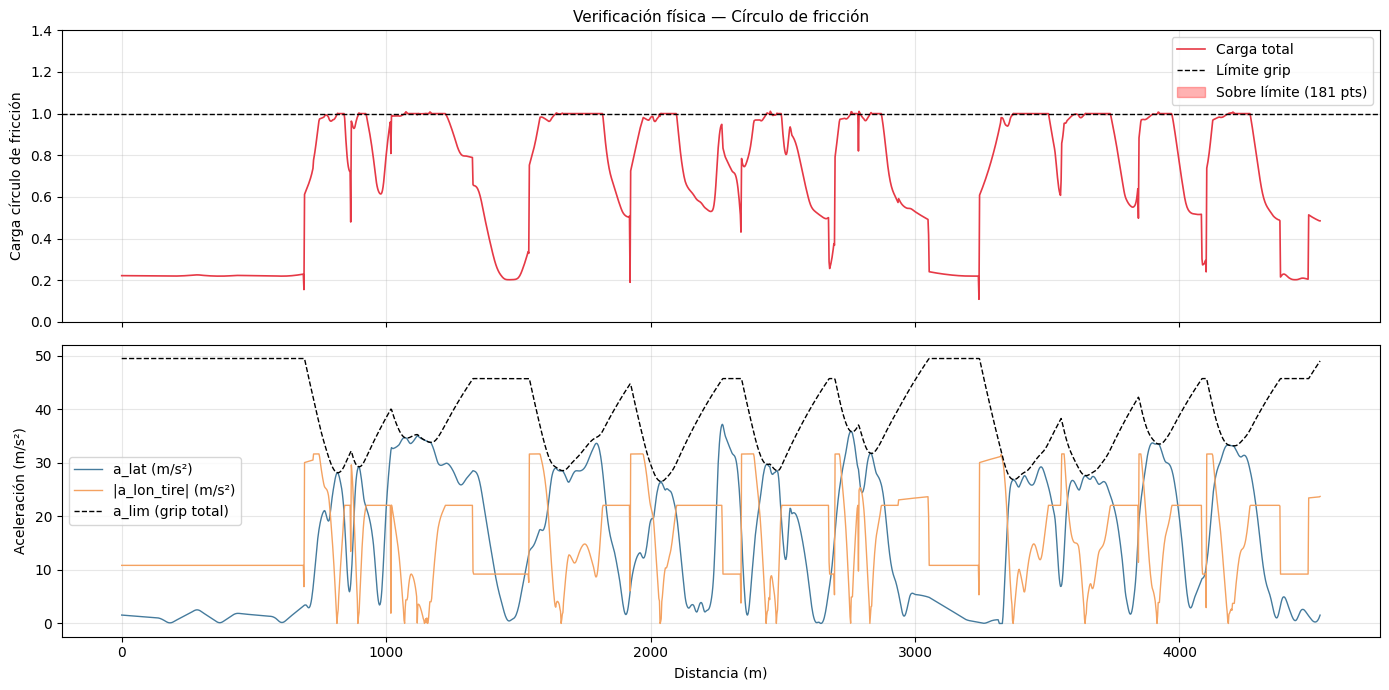

In [9]:
# ── Verificación física — círculo de fricción ──────────────────────────────────
#
# El drag es externo al neumático. La fuerza longitudinal que SÍ consume grip es:
#   a_lon_tire = a_lon_signed + k_drag·v²
# (en frenada el drag ayuda → el neumático necesita menos; en aceleración penaliza)
#
# Condición:  sqrt((a_lat/a_lim)² + (a_lon_tire/a_lim)²) ≤ 1

a_lat = v_to**2 * kappa_to_s

dv2          = np.diff(v_to**2)
a_lon_signed = np.append(dv2 / (2 * ds_to), dv2[-1] / (2 * ds_to[-1]))
a_lon_tire   = a_lon_signed + k_drag * v_to**2

a_lim = MU * G + k_downforce * v_to**2
carga = np.sqrt((a_lat / a_lim)**2 + (a_lon_tire / a_lim)**2)

violaciones = carga > 1.0
n_viol      = violaciones.sum()
carga_max   = carga.max()
exceso_max  = (carga_max - 1.0) * 100   # % sobre el límite

print('=== VERIFICACIÓN FÍSICA — CÍRCULO DE FRICCIÓN ===')
print(f'  Carga máxima:        {carga_max:.4f}  (límite = 1.0)')
print(f'  Exceso máximo:       {exceso_max:.2f}%')
print(f'  Carga media:         {carga.mean():.4f}')
print(f'  Puntos sobre límite: {n_viol} / {len(carga)}  ({n_viol/len(carga)*100:.1f}%)')
print()
if carga_max <= 1.0:
    print('✅ Trayectoria físicamente factible. Ningún punto excede el grip disponible.')
elif exceso_max < 3.0:
    print(f'✅ Factible. Exceso máximo {exceso_max:.2f}% — dentro del error de discretización')
    print(f'   (espaciado ~{ds_to.mean():.1f}m entre puntos). Muchos puntos cerca del límite')
    print('   es el comportamiento esperado de una trayectoria tiempo-óptima.')
else:
    print(f'⚠️  Exceso máximo {exceso_max:.1f}% — la trayectoria no es físicamente ejecutable.')

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.plot(dist_to, carga, lw=1.2, color='#e63946', label='Carga total')
ax.axhline(1.0, color='black', lw=1.0, ls='--', label='Límite grip')
ax.fill_between(dist_to, carga, 1.0,
                where=(carga > 1.0), color='red', alpha=0.3, label=f'Sobre límite ({n_viol} pts)')
ax.set_ylabel('Carga círculo de fricción')
ax.set_ylim([0, max(1.4, carga_max + 0.1)])
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title('Verificación física — Círculo de fricción', fontsize=11)

ax = axes[1]
ax.plot(dist_to, a_lat,              lw=1.0, color='#457b9d', label='a_lat (m/s²)')
ax.plot(dist_to, np.abs(a_lon_tire), lw=1.0, color='#f4a261', label='|a_lon_tire| (m/s²)')
ax.plot(dist_to, a_lim,              lw=1.0, color='black',   ls='--', label='a_lim (grip total)')
ax.set_xlabel('Distancia (m)')
ax.set_ylabel('Aceleración (m/s²)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# ── Resumen final ──────────────────────────────────────────────────────────────
diferencia_pole  = t_final - POLE_TIME
mejora_vs_centro = t_centro_cal - t_final

print('=' * 55)
print('   RESUMEN FINAL')
print('=' * 55)
print(f'  Pole Norris (real):          {POLE_TIME:.3f} s')
print(f'  Línea de referencia (cal.):  {t_centro_cal:.3f} s  ({t_centro_cal - POLE_TIME:+.3f} s vs pole)')
print(f'  Trayectoria tiempo-óptima:   {t_final:.3f} s  ({diferencia_pole:+.3f} s vs pole)')
print()
print(f'  Mejora vs línea de referencia: {mejora_vs_centro:+.3f} s')
drs_pct = drs_mask.sum() / N * 100
print(f'  Zonas DRS activas: {drs_pct:.1f}% de la vuelta (k_drag × {DRS_FACTOR})')

   RESUMEN FINAL
  Pole Norris (real):          71.383 s
  Línea de referencia (cal.):  71.657 s  (+0.274 s vs pole)
  Trayectoria tiempo-óptima:   70.049 s  (-1.334 s vs pole)

  Mejora vs línea de referencia: +1.608 s
  Zonas DRS activas: 25.7% de la vuelta (k_drag × 0.85)


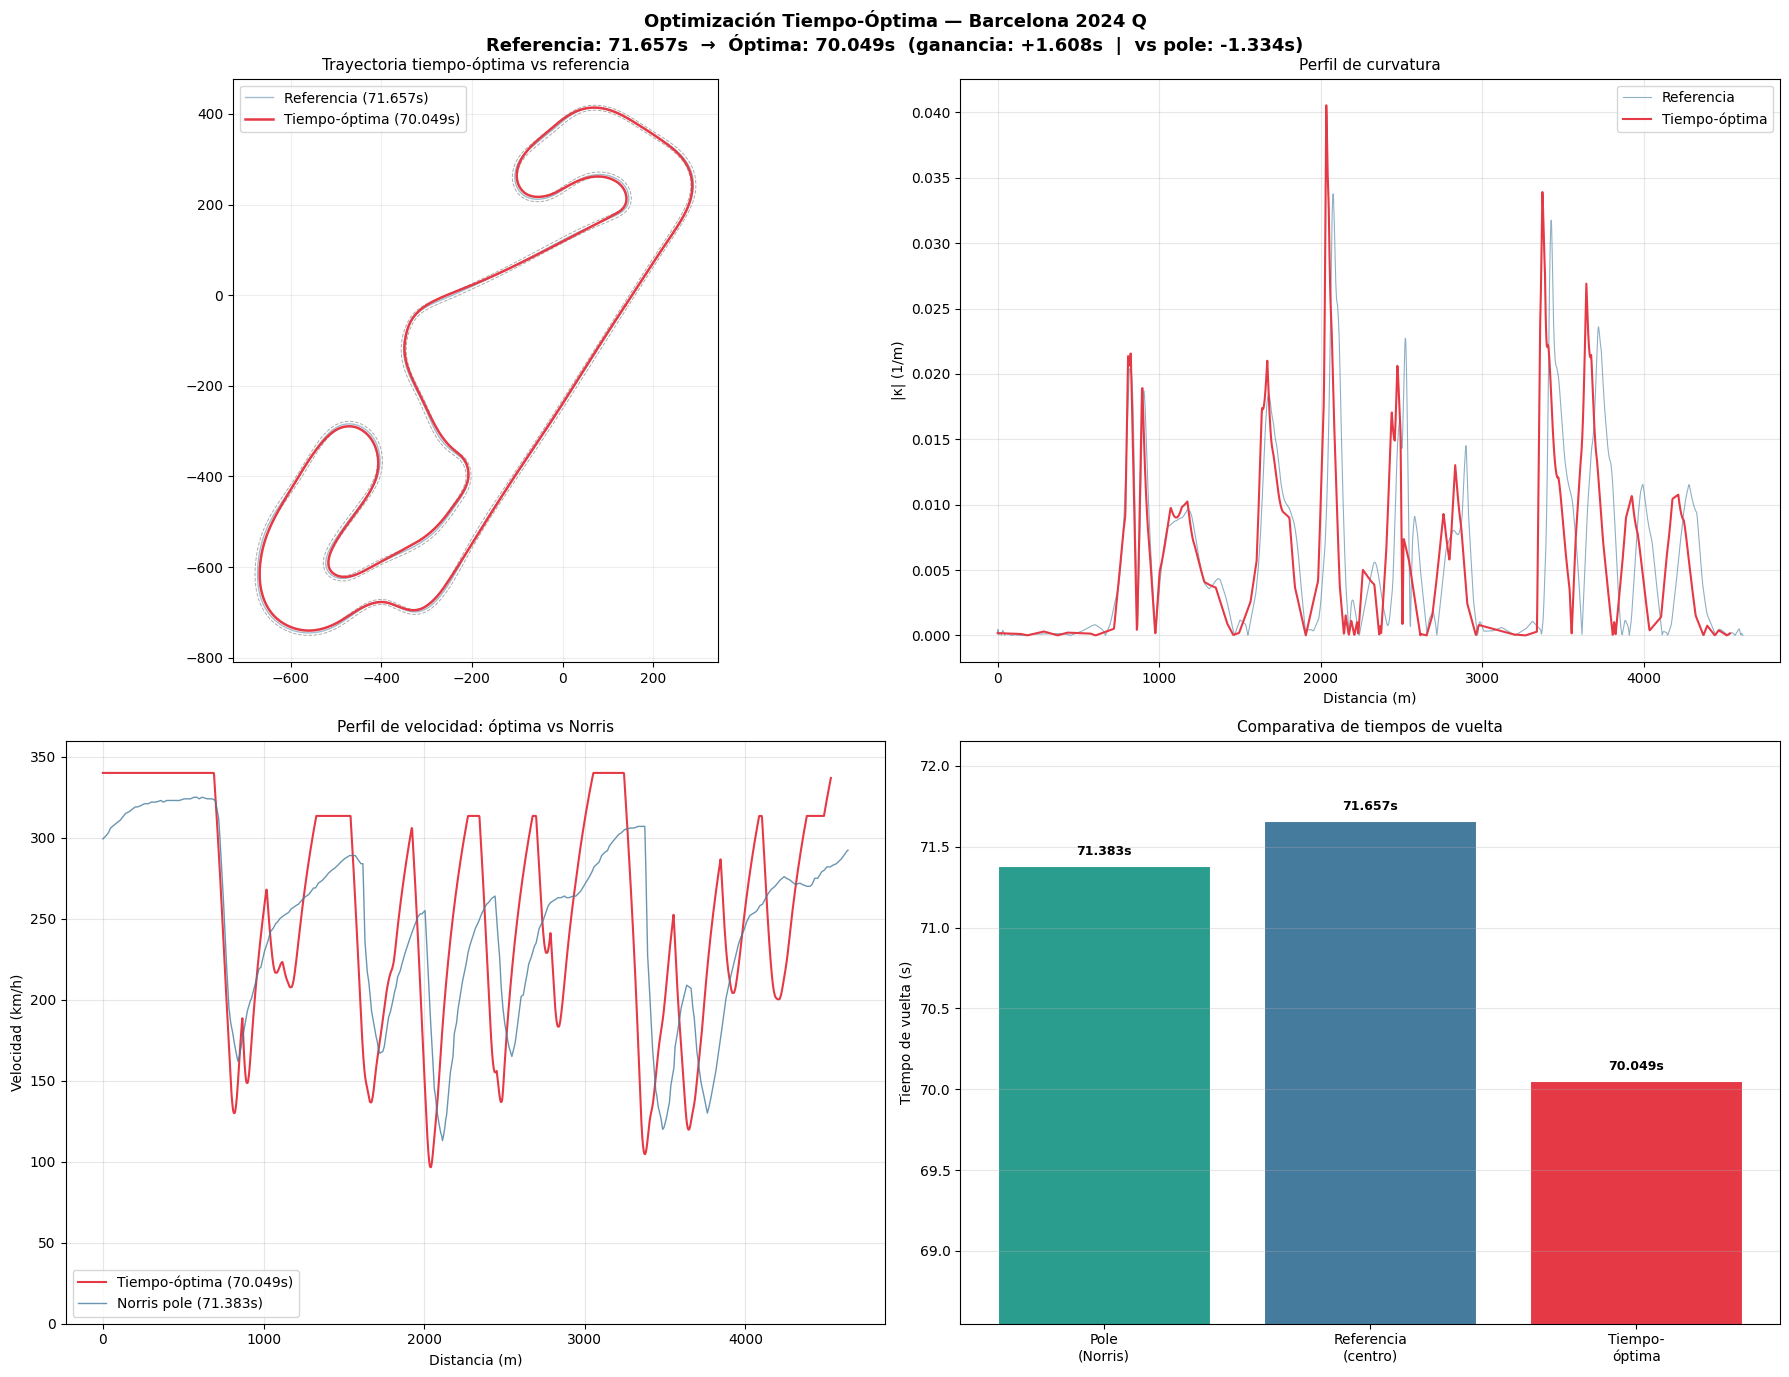

In [11]:
# ── Visualizaciones ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

x_izq = x_ref + nx * d_max;  y_izq = y_ref + ny * d_max
x_der = x_ref - nx * d_max;  y_der = y_ref - ny * d_max

# --- 1. Comparativa de trayectorias ---
ax = axes[0, 0]
ax.plot(x_izq, y_izq, lw=0.7, color='#aaa', ls='--')
ax.plot(x_der, y_der, lw=0.7, color='#aaa', ls='--')
ax.plot(x_ref, y_ref, lw=1.0, color='#457b9d', alpha=0.5, label=f'Referencia ({t_centro_cal:.3f}s)')
ax.plot(x_to,  y_to,  lw=1.8, color='#e63946',             label=f'Tiempo-óptima ({t_final:.3f}s)')
ax.set_aspect('equal')
ax.legend(fontsize=10)
ax.set_title('Trayectoria tiempo-óptima vs referencia', fontsize=11)
ax.grid(True, alpha=0.2)

# --- 2. Perfil de curvatura ---
ax = axes[0, 1]
ax.plot(dist_ref, np.abs(kappa_ref), lw=0.8, color='#457b9d', alpha=0.6, label='Referencia')
ax.plot(dist_to,  np.abs(kappa_to),  lw=1.5, color='#e63946',             label='Tiempo-óptima')
ax.set_xlabel('Distancia (m)')
ax.set_ylabel('|κ| (1/m)')
ax.set_title('Perfil de curvatura', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)

# --- 3. Perfil de velocidad ---
ax = axes[1, 0]
ax.plot(dist_to, v_to * 3.6, lw=1.5, color='#e63946',
        label=f'Tiempo-óptima ({t_final:.3f}s)')
# Añadir telemetría real de Norris
ax.plot(dist_tel, v_tel * 3.6, lw=1.0, color='#457b9d', alpha=0.8,
        label=f'Norris pole ({POLE_TIME:.3f}s)')
ax.set_xlabel('Distancia (m)')
ax.set_ylabel('Velocidad (km/h)')
ax.set_title('Perfil de velocidad: óptima vs Norris', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 360])

# --- 4. Diagrama de barras ---
ax = axes[1, 1]
labels_bar  = ['Pole\n(Norris)', 'Referencia\n(centro)', 'Tiempo-\nóptima']
tiempos_bar = [POLE_TIME, t_centro_cal, t_final]
colors_bar  = ['#2a9d8f', '#457b9d', '#e63946']
bars = ax.bar(labels_bar, tiempos_bar, color=colors_bar, edgecolor='white', linewidth=1.5)
ax.set_ylabel('Tiempo de vuelta (s)')
ax.set_title('Comparativa de tiempos de vuelta', fontsize=11)
ax.set_ylim([min(tiempos_bar) - 1.5, max(tiempos_bar) + 0.5])
for bar, t in zip(bars, tiempos_bar):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{t:.3f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(
    f'Optimización Tiempo-Óptima — Barcelona 2024 Q\n'
    f'Referencia: {t_centro_cal:.3f}s  →  Óptima: {t_final:.3f}s  '
    f'(ganancia: {t_centro_cal - t_final:+.3f}s  |  vs pole: {t_final - POLE_TIME:+.3f}s)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

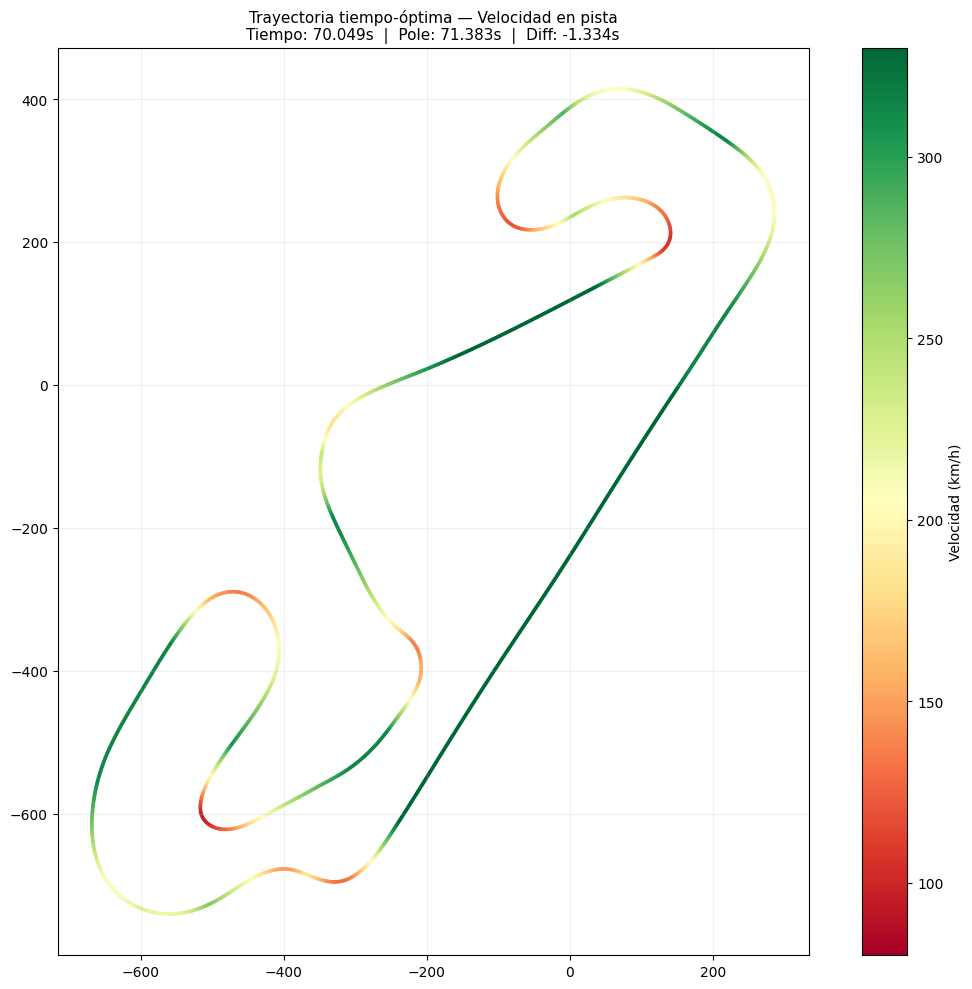

In [12]:
# ── Mapa de velocidad en circuito ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 10))
sc = ax.scatter(x_to, y_to, c=v_to * 3.6, cmap='RdYlGn', s=3, vmin=80, vmax=330)
plt.colorbar(sc, ax=ax, label='Velocidad (km/h)')
ax.set_aspect('equal')
ax.set_title(
    f'Trayectoria tiempo-óptima — Velocidad en pista\n'
    f'Tiempo: {t_final:.3f}s  |  Pole: {POLE_TIME:.3f}s  |  Diff: {diferencia_pole:+.3f}s',
    fontsize=11
)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [13]:
# ── Guardar resultados ─────────────────────────────────────────────────────────
tray_opt_t = pd.DataFrame({
    'x':                x_to,
    'y':                y_to,
    'kappa':            kappa_to,
    'dist':             dist_to,
    'n_desplazamiento': n_opt_smooth,
    'velocidad':        v_to,
})

tray_opt_t.to_csv('../data/trayectoria_tiempo_optima_barcelona_2024.csv', index=False)

print(f'✅ Guardado: ../data/trayectoria_tiempo_optima_barcelona_2024.csv')
print(f'   {len(tray_opt_t)} puntos')
print(f'   Longitud:              {dist_to[-1]:.1f} m')
print(f'   Tiempo vuelta:         {t_final:.3f} s')
print(f'   Mejora vs referencia:  {mejora_vs_centro:+.3f} s')
print(f'   Diff vs pole:          {diferencia_pole:+.3f} s')

✅ Guardado: ../data/trayectoria_tiempo_optima_barcelona_2024.csv
   2000 puntos
   Longitud:              4531.7 m
   Tiempo vuelta:         70.049 s
   Mejora vs referencia:  +1.608 s
   Diff vs pole:          -1.334 s
